# Compare Runs

Load every `summary.json` under `results/` and visualize entity-level F1, per-class F1, precision/recall, and training time across runs.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR

PosixPath('/Users/dayanbattulga/Desktop/personal-code/misc/dunedain_ner/results')

In [2]:
summary_paths = sorted(RESULTS_DIR.glob('*/summary.json'))
print(f'Found {len(summary_paths)} summary.json files:')
for p in summary_paths:
    print(' -', p.relative_to(REPO_ROOT))

Found 31 summary.json files:
 - results/deberta_efficient_align_off_seed5768/summary.json
 - results/deberta_efficient_align_off_seed78516/summary.json
 - results/deberta_efficient_align_off_seed88/summary.json
 - results/deberta_efficient_lr1e5_seed5768/summary.json
 - results/deberta_efficient_lr1e5_seed78516/summary.json
 - results/deberta_efficient_lr1e5_seed88/summary.json
 - results/deberta_efficient_lr2e5_seed5768/summary.json
 - results/deberta_efficient_lr2e5_seed78516/summary.json
 - results/deberta_efficient_lr2e5_seed88/summary.json
 - results/deberta_efficient_seed5768/summary.json
 - results/deberta_efficient_seed5768_seed5768/summary.json
 - results/deberta_efficient_seed78516/summary.json
 - results/deberta_efficient_seed78516_seed78516/summary.json
 - results/deberta_efficient_seed88/summary.json
 - results/deberta_efficient_seed88_seed88/summary.json
 - results/efficient_after_dapt_logit_ensemble/summary.json
 - results/efficient_after_dapt_seed5768/summary.json
 - re

In [4]:
def load_summary(path: Path) -> dict:
    with open(path) as f:
        data = json.load(f)
    cfg = data.get('config', {})
    val = data.get('val_metrics', {}) or {}
    test = data.get('test_metrics', {}) or {}
    val_per = val.get('entity_per_class', {})
    test_per = test.get('entity_per_class', {})
    return {
        'run_id': data.get('run_id', path.parent.name),
        'model': cfg.get('model_name'),
        'seed': cfg.get('resolved_seed', (cfg.get('seeds') or [None])[0]),
        'use_crf': cfg.get('use_crf', False),
        'num_epochs': cfg.get('num_epochs'),
        'lr': cfg.get('learning_rate'),
        'param_count': data.get('param_count'),
        'train_time_min': data.get('train_time_min'),
        'best_val_entity_f1': data.get('best_validation_entity_f1'),
        'val_token_f1': val.get('token_weighted_f1'),
        'val_entity_f1': val.get('entity_overall_f1'),
        'val_entity_precision': val.get('entity_overall_precision'),
        'val_entity_recall': val.get('entity_overall_recall'),
        'val_per_f1': val_per.get('PER'),
        'val_loc_f1': val_per.get('LOC'),
        'val_org_f1': val_per.get('ORG'),
        'test_token_f1': test.get('token_weighted_f1'),
        'test_entity_f1': test.get('entity_overall_f1'),
        'test_entity_precision': test.get('entity_overall_precision'),
        'test_entity_recall': test.get('entity_overall_recall'),
        'test_per_f1': test_per.get('PER'),
        'test_loc_f1': test_per.get('LOC'),
        'test_org_f1': test_per.get('ORG'),
    }

rows = [load_summary(p) for p in summary_paths]
df = pd.DataFrame(rows).sort_values('run_id').reset_index(drop=True)
df

,run_id,model,seed,use_crf,use_distillation,num_epochs,lr,param_count,train_time_min,best_val_entity_f1,...,val_per_f1,val_loc_f1,val_org_f1,test_token_f1,test_entity_f1,test_entity_precision,test_entity_recall,test_per_f1,test_loc_f1,test_org_f1
0,deberta_efficient_align_off_seed5768,microsoft/deberta-v3-large,5768.0,False,False,5.0,0.00002,434019335.0,8.513198,0.912541,...,0.974729,0.912821,0.880734,0.984188,0.830885,0.795820,0.869183,0.934744,0.817891,0.788235
1,deberta_efficient_align_off_seed78516,microsoft/deberta-v3-large,78516.0,False,False,5.0,0.00002,434019335.0,8.528727,0.911814,...,0.981949,0.929870,0.862963,0.984427,0.836240,0.811056,0.863038,0.934513,0.829032,0.792453
2,deberta_efficient_align_off_seed88,microsoft/deberta-v3-large,88.0,False,False,5.0,0.00002,434019335.0,8.511463,0.906689,...,0.985507,0.925831,0.852941,0.984206,0.834599,0.803412,0.868306,0.935201,0.835726,0.784983
3,deberta_efficient_lr1e5_seed5768,microsoft/deberta-v3-large,5768.0,False,False,5.0,0.00001,434019335.0,8.481375,0.910891,...,0.978417,0.914141,0.873606,0.982664,0.825157,0.789727,0.863916,0.949033,0.812102,0.772727
4,deberta_efficient_lr1e5_seed78516,microsoft/deberta-v3-large,78516.0,False,False,5.0,0.00001,434019335.0,8.477838,0.899585,...,0.978571,0.919897,0.843866,0.982738,0.829536,0.798538,0.863038,0.944056,0.819355,0.779287
5,deberta_efficient_lr1e5_seed88,microsoft/deberta-v3-large,88.0,False,False,5.0,0.00001,434019335.0,8.417920,0.893827,...,0.971014,0.916031,0.838828,0.982177,0.829778,0.792332,0.870939,0.945518,0.821485,0.778806
6,deberta_efficient_lr2e5_seed5768,microsoft/deberta-v3-large,5768.0,False,False,5.0,0.00002,434019335.0,8.547270,0.905350,...,0.967742,0.913706,0.867159,0.982607,0.825941,0.788969,0.866550,0.945326,0.812598,0.776094
7,deberta_efficient_lr2e5_seed78516,microsoft/deberta-v3-large,78516.0,False,False,5.0,0.00002,434019335.0,8.522555,0.908036,...,0.974910,0.922280,0.863469,0.983400,0.836855,0.806846,0.869183,0.938918,0.830918,0.790102
8,deberta_efficient_lr2e5_seed88,microsoft/deberta-v3-large,88.0,False,False,5.0,0.00002,434019335.0,8.488023,0.904020,...,0.985612,0.913706,0.855576,0.983119,0.834797,0.797125,0.876207,0.942207,0.830964,0.785173
9,deberta_efficient_seed5768_seed5768,microsoft/deberta-v3-large,5768.0,False,False,5.0,0.00005,434019335.0,8.169544,0.917355,...,0.992754,0.923077,0.875000,0.983737,0.839413,0.803371,0.878841,0.940351,0.839937,0.790541


## Overall entity F1 (validation vs test)

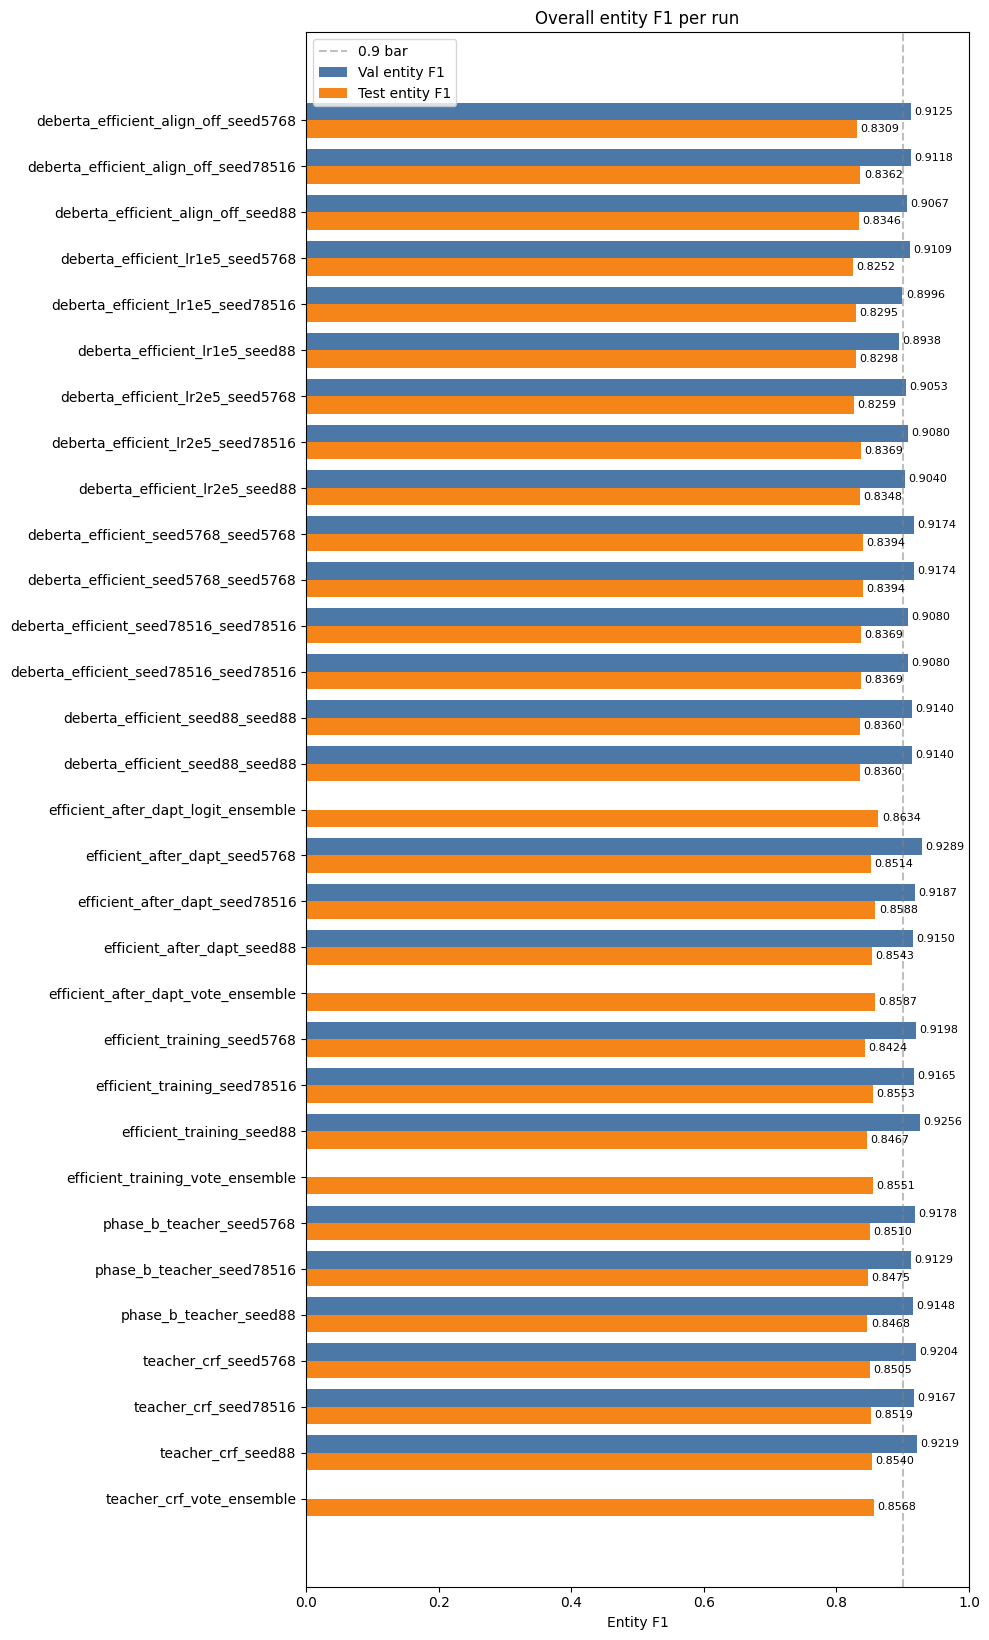

In [5]:
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.38
ax.barh(y - h/2, df['val_entity_f1'].fillna(0), h, label='Val entity F1', color='#4C78A8')
ax.barh(y + h/2, df['test_entity_f1'].fillna(0), h, label='Test entity F1', color='#F58518')
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Entity F1')
ax.set_xlim(0, 1)
ax.axvline(0.9, linestyle='--', color='gray', alpha=0.5, label='0.9 bar')
ax.legend(loc='upper left')
ax.invert_yaxis()
ax.set_title('Overall entity F1 per run')
for i, (v, t) in enumerate(zip(df['val_entity_f1'], df['test_entity_f1'])):
    if pd.notna(v):
        ax.text(v + 0.005, i - h/2, f'{v:.4f}', va='center', fontsize=8)
    if pd.notna(t):
        ax.text(t + 0.005, i + h/2, f'{t:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Per-class entity F1 on test set

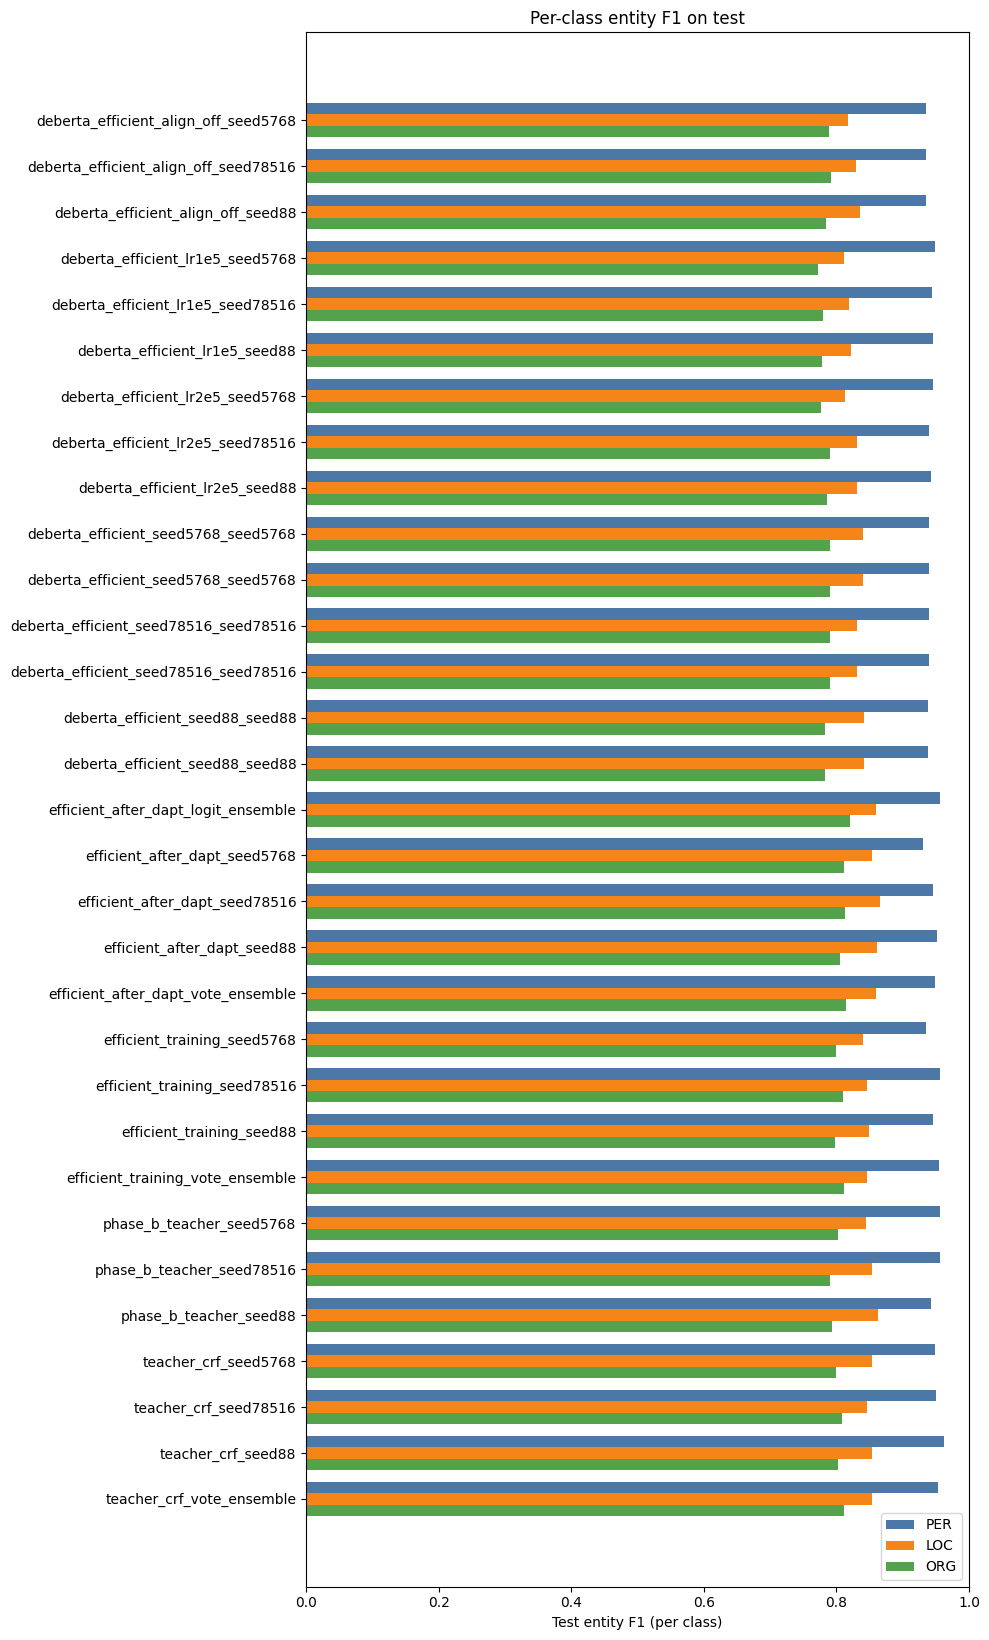

In [6]:
classes = ['PER', 'LOC', 'ORG']
cols = ['test_per_f1', 'test_loc_f1', 'test_org_f1']
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.25
colors = ['#4C78A8', '#F58518', '#54A24B']
for i, (c, col, color) in enumerate(zip(classes, cols, colors)):
    offset = (i - 1) * h
    ax.barh(y + offset, df[col].fillna(0), h, label=c, color=color)
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Test entity F1 (per class)')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_title('Per-class entity F1 on test')
plt.tight_layout()
plt.show()

## Precision / Recall / F1 on test set

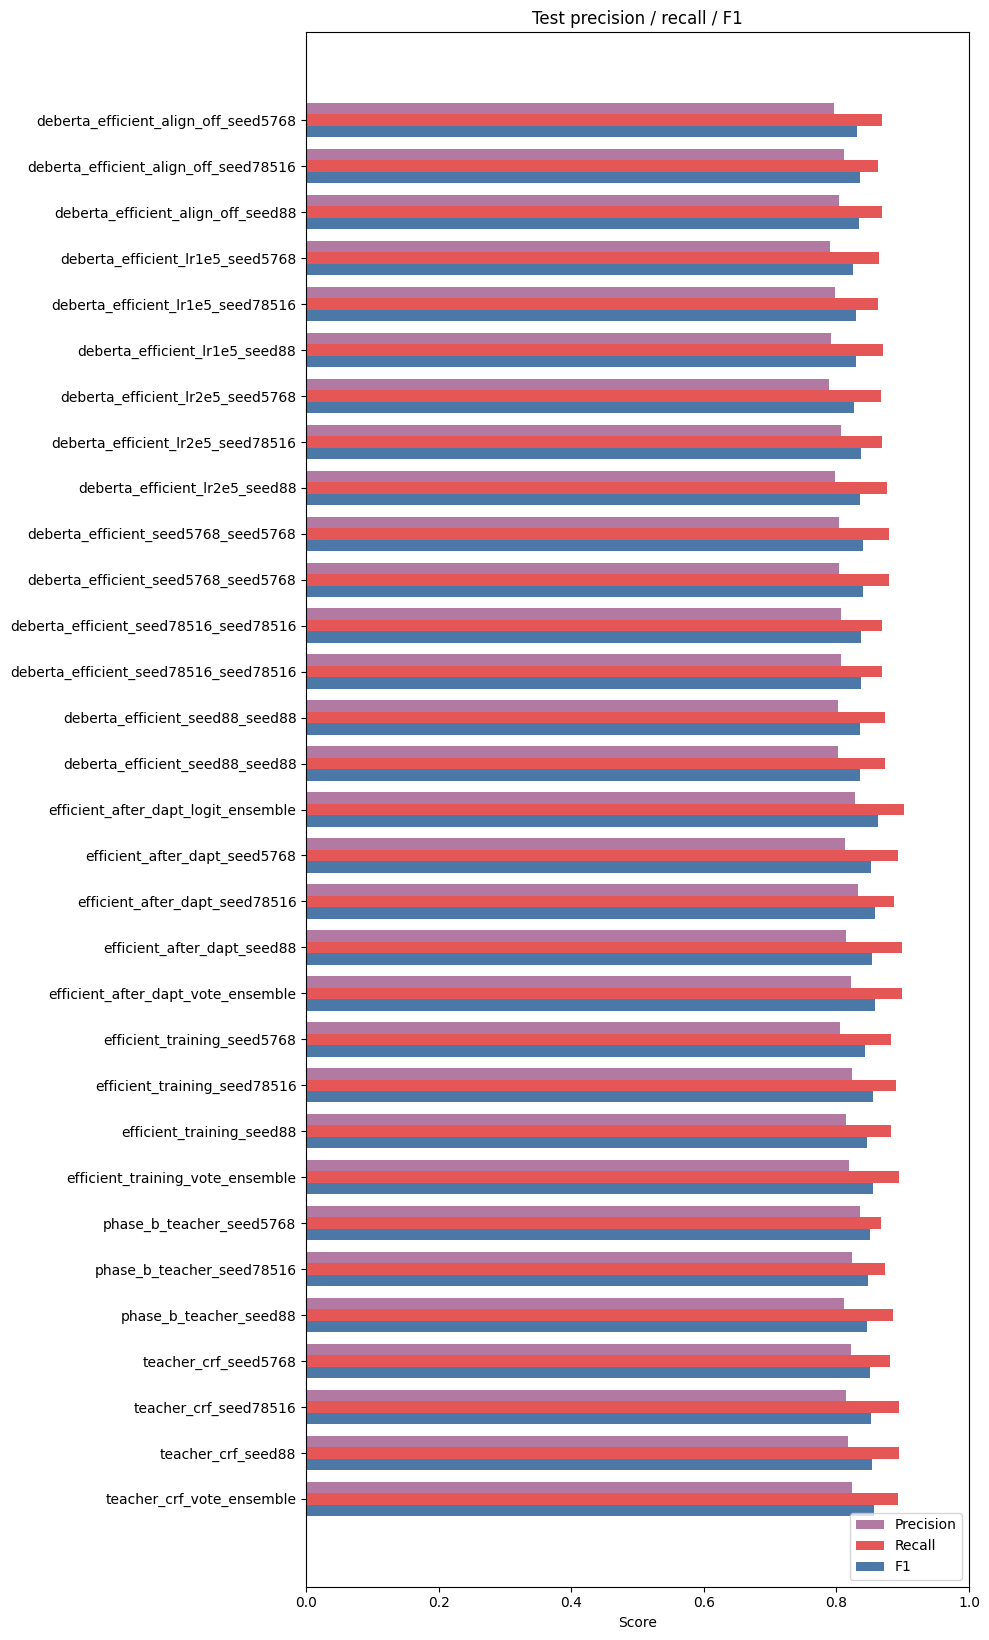

In [7]:
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.25
ax.barh(y - h, df['test_entity_precision'].fillna(0), h, label='Precision', color='#B279A2')
ax.barh(y,      df['test_entity_recall'].fillna(0),    h, label='Recall',    color='#E45756')
ax.barh(y + h,  df['test_entity_f1'].fillna(0),        h, label='F1',        color='#4C78A8')
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Score')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_title('Test precision / recall / F1')
plt.tight_layout()
plt.show()

## Train time vs test entity F1

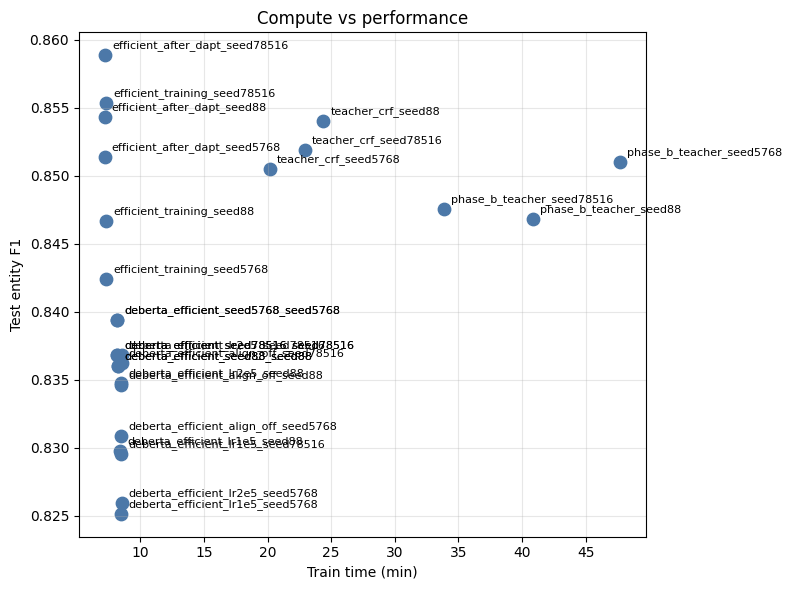

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sub = df.dropna(subset=['train_time_min', 'test_entity_f1'])
ax.scatter(sub['train_time_min'], sub['test_entity_f1'], s=80, color='#4C78A8')
for _, row in sub.iterrows():
    ax.annotate(row['run_id'], (row['train_time_min'], row['test_entity_f1']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Train time (min)')
ax.set_ylabel('Test entity F1')
ax.set_title('Compute vs performance')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Seed aggregation (mean ± std by model / variant)

In [9]:
def variant(row):
    tag = row['model'] or 'unknown'
    if row['use_crf']:
        tag += '+crf'
    return tag

df['variant'] = df.apply(variant, axis=1)
# strip seed suffix so multi-seed runs collapse
df['run_group'] = df['run_id'].str.replace(r'_seed\d+$', '', regex=True)

agg_cols = ['test_entity_f1', 'test_per_f1', 'test_loc_f1', 'test_org_f1', 'test_token_f1']
agg = df.groupby('run_group')[agg_cols].agg(['mean', 'std', 'count'])
agg

test_entity_f1                  \
                                              mean       std count   
run_group                                                            
deberta_efficient_align_off               0.833908  0.002743     3   
deberta_efficient_lr1e5                   0.828157  0.002601     3   
deberta_efficient_lr2e5                   0.832531  0.005799     3   
deberta_efficient_seed5768                0.839413  0.000000     2   
deberta_efficient_seed78516               0.836855  0.000000     2   
deberta_efficient_seed88                  0.835997  0.000000     2   
efficient_after_dapt                      0.854842  0.003752     3   
efficient_after_dapt_logit_ensemble       0.863388       NaN     1   
efficient_after_dapt_vote_ensemble        0.858700       NaN     1   
efficient_training                        0.848141  0.006585     3   
efficient_training_vote_ensemble          0.855103       NaN     1   
phase_b_teacher                           0.848451  0.002227     3   
teacher_crf                               0.852132  0.001783     3   
teacher_crf_vote_ensemble                 0.856782       NaN     1   

                                    test_per_f1                 test_loc_f1  \
                                           mean       std count        mean   
run_group                                                                     
deberta_efficient_align_off            0.934820  0.000350     3    0.827550   
deberta_efficient_lr1e5                0.946203  0.002558     3    0.817647   
deberta_efficient_lr2e5                0.942150  0.003205     3    0.824827   
deberta_efficient_seed5768             0.940351  0.000000     2    0.839937   
deberta_efficient_seed78516            0.938918  0.000000     2    0.830918   
deberta_efficient_seed88               0.938704  0.000000     2    0.841270   
efficient_after_dapt                   0.942518  0.010497     3    0.860226   
efficient_after_dapt_logit_ensemble    0.956370       NaN     1    0.858974   
efficient_after_dapt_vote_ensemble     0.949389       NaN     1    0.858974   
efficient_training                     0.945874  0.010660     3    0.844899   
efficient_training_vote_ensemble       0.954704       NaN     1    0.846276   
phase_b_teacher                        0.951780  0.007552     3    0.853818   
teacher_crf                            0.953112  0.007450     3    0.850969   
teacher_crf_vote_ensemble              0.953043       NaN     1    0.853968   

                                                    test_org_f1            \
                                          std count        mean       std   
run_group                                                                   
deberta_efficient_align_off          0.009009     3    0.788557  0.003745   
deberta_efficient_lr1e5              0.004919     3    0.776940  0.003656   
deberta_efficient_lr2e5              0.010590     3    0.783790  0.007106   
deberta_efficient_seed5768           0.000000     2    0.790541  0.000000   
deberta_efficient_seed78516          0.000000     2    0.790102  0.000000   
deberta_efficient_seed88             0.000000     2    0.783347  0.000000   
efficient_after_dapt                 0.005561     3    0.809506  0.004259   
efficient_after_dapt_logit_ensemble       NaN     1    0.820643       NaN   
efficient_after_dapt_vote_ensemble        NaN     1    0.814815       NaN   
efficient_training                   0.004437     3    0.802187  0.007078   
efficient_training_vote_ensemble          NaN     1    0.811224       NaN   
phase_b_teacher                      0.009169     3    0.795355  0.006075   
teacher_crf                          0.004845     3    0.803161  0.004182   
teacher_crf_vote_ensemble                 NaN     1    0.810950       NaN   

                                          test_token_f1                  
                                    count          mean       std count  
run_group                                  

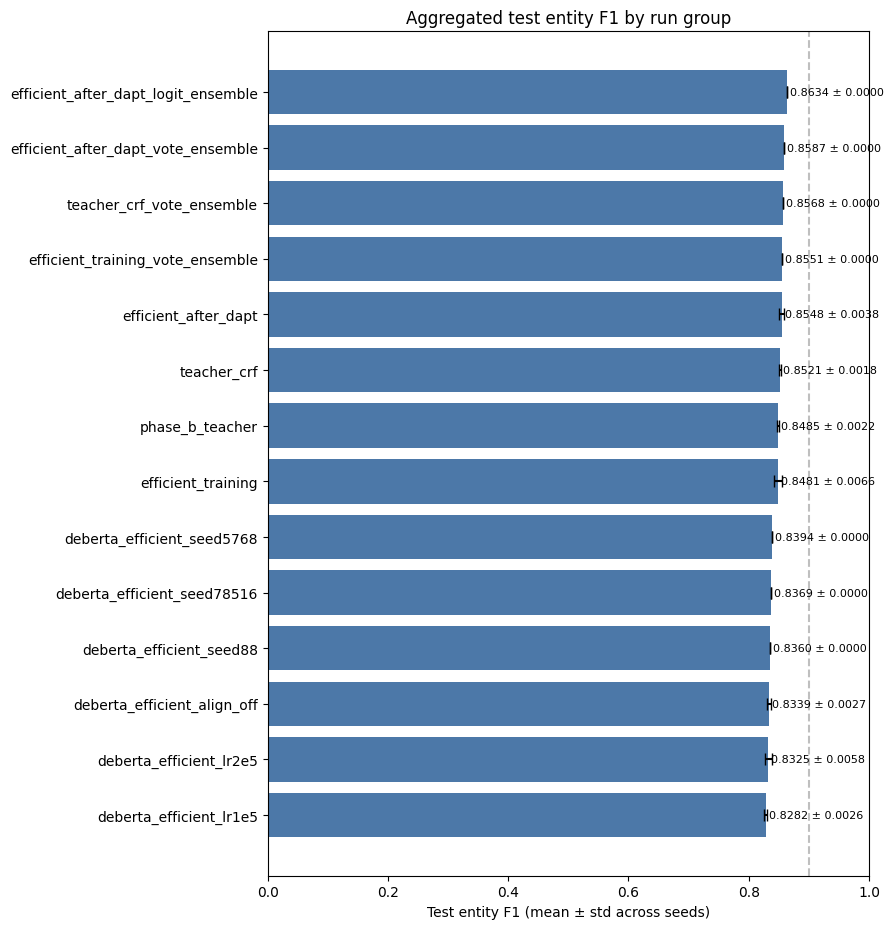

In [10]:
means = df.groupby('run_group')['test_entity_f1'].mean()
stds = df.groupby('run_group')['test_entity_f1'].std().fillna(0)
order = means.sort_values().index
fig, ax = plt.subplots(figsize=(9, max(3, 0.6 * len(order) + 1)))
y = np.arange(len(order))
ax.barh(y, means.loc[order], xerr=stds.loc[order], color='#4C78A8', capsize=4)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel('Test entity F1 (mean ± std across seeds)')
ax.set_xlim(0, 1)
ax.axvline(0.9, linestyle='--', color='gray', alpha=0.5)
ax.set_title('Aggregated test entity F1 by run group')
for i, g in enumerate(order):
    ax.text(means.loc[g] + 0.005, i, f'{means.loc[g]:.4f} ± {stds.loc[g]:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Raw comparison table

In [48]:
display_cols = ['run_id', 'model', 'seed', 'num_epochs', 'param_count', 'train_time_min',
                'best_val_entity_f1', 'val_entity_f1', 'test_entity_f1',
                'test_per_f1', 'test_loc_f1', 'test_org_f1']
df[display_cols].style.format({
    'best_val_entity_f1': '{:.4f}',
    'val_entity_f1': '{:.4f}',
    'test_entity_f1': '{:.4f}',
    'test_per_f1': '{:.4f}',
    'test_loc_f1': '{:.4f}',
    'test_org_f1': '{:.4f}',
    'train_time_min': '{:.2f}',
    'param_count': '{:,.0f}',
}, na_rep='-')

,run_id,model,seed,num_epochs,param_count,train_time_min,best_val_entity_f1,val_entity_f1,test_entity_f1,test_per_f1,test_loc_f1,test_org_f1
0,deberta_efficient_seed5768_seed5768,microsoft/deberta-v3-large,5768,5,"434,019,335",8.17,0.9174,0.9174,0.8394,0.9404,0.8399,0.7905
1,deberta_efficient_seed5768_seed5768,microsoft/deberta-v3-large,5768,5,"434,019,335",8.17,0.9174,0.9174,0.8394,0.9404,0.8399,0.7905
2,deberta_efficient_seed78516_seed78516,microsoft/deberta-v3-large,78516,5,"434,019,335",8.19,0.9080,0.9080,0.8369,0.9389,0.8309,0.7901
3,deberta_efficient_seed78516_seed78516,microsoft/deberta-v3-large,78516,5,"434,019,335",8.19,0.9080,0.9080,0.8369,0.9389,0.8309,0.7901
4,deberta_efficient_seed88_seed88,microsoft/deberta-v3-large,88,5,"434,019,335",8.21,0.9140,0.9140,0.8360,0.9387,0.8413,0.7833
5,deberta_efficient_seed88_seed88,microsoft/deberta-v3-large,88,5,"434,019,335",8.21,0.9140,0.9140,0.8360,0.9387,0.8413,0.7833
6,efficient_training_seed5768,roberta-large,5768,5,"355,366,982",7.31,0.9198,0.9198,0.8424,0.9352,0.8399,0.7990
7,efficient_training_seed78516,roberta-large,78516,5,"355,366,982",7.31,0.9165,0.9165,0.8553,0.9565,0.8463,0.8103
8,efficient_training_seed88,roberta-large,88,5,"355,366,982",7.32,0.9256,0.9256,0.8467,0.9459,0.8485,0.7973
9,phase_b_teacher_seed5768,roberta-large,5768,30,"354,317,319",47.72,0.9178,0.9178,0.8510,0.9562,0.8444,0.8021
